# Python-Based Statistical Computation Workflow

This notebook analyzes the attached checkerboard assay results using a reproducible Python workflow. It performs data parsing, cleaning, MIC and ΣFIC verification, descriptive statistics, assumption checks, exploratory inferential tests, effect-size estimation, and publication-ready outputs.

Because the workbook contains three assay sets, inferential tests are included only as exploratory analyses. The main statistically defensible analysis is descriptive, supported by consistency checks and effect-size reporting.

## Statistical analysis plan

**Independent variables:** erythromycin concentration, carbon-dots concentration, and assay set/replicate.

**Dependent variables:** visible response (T or SC), carbon-dots MIC in combination, computed ΣFIC index, and FIC interpretation.

**Primary endpoint:** computed ΣFIC index.

**Recommended interpretation:** prioritize descriptive statistics and consistency checks because there are only three assay sets. Use the Friedman test only as an exploratory repeated-measures comparison across erythromycin concentrations.

In [3]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH = Path("Results (1).xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Results (1).xlsx")

OUTPUT_DIR = Path("statistical_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Using data file: {DATA_PATH}")

Using data file: Results (1).xlsx


In [4]:
def clean_token(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("\t", "").strip()

def parse_concentration(x):
    s = clean_token(x)
    if pd.isna(s):
        return np.nan, None
    m = re.search(r"([0-9]*\.?[0-9]+)\s*(ug|µg|mcg|mg)\s*/\s*mL", s, flags=re.I)
    if not m:
        return np.nan, None
    value = float(m.group(1))
    unit = m.group(2).lower().replace("µ", "u").replace("mcg", "ug") + "/mL"
    return value, unit

def classify_fici(x):
    if pd.isna(x):
        return np.nan
    if x <= 0.5:
        return "Synergistic"
    if x <= 1.0:
        return "Additive"
    if x <= 4.0:
        return "Indifferent"
    return "Antagonistic"

def fix_constant_ci(df, mean_col="mean_fic", sd_col="sd_fic", low_col="ci95_low", high_col="ci95_high"):
    mask = df[sd_col].fillna(0) == 0
    df.loc[mask, low_col] = df.loc[mask, mean_col]
    df.loc[mask, high_col] = df.loc[mask, mean_col]
    return df

def parse_workbook(path):
    raw = pd.read_excel(path, sheet_name="Sheet1", header=None)

    ery_mic_values = [parse_concentration(raw.iloc[7, c])[0] for c in [1, 2, 3]]
    cd_mic_values = [parse_concentration(raw.iloc[16, c])[0] for c in [1, 2, 3]]

    ery_mic_alone = float(np.nanmean(ery_mic_values))
    cd_mic_alone = float(np.nanmean(cd_mic_values))

    response_records = []
    fic_records = []

    for set_number, start_row in [(1, 18), (2, 28), (3, 38)]:
        ery_columns = []
        for col in range(2, 7):
            ery_value, ery_unit = parse_concentration(raw.iloc[start_row + 1, col])
            ery_columns.append((col, ery_value, ery_unit))

        for row in range(start_row + 2, start_row + 7):
            cd_value, cd_unit = parse_concentration(raw.iloc[row, 1])
            for col, ery_value, ery_unit in ery_columns:
                response_records.append({
                    "set": set_number,
                    "carbon_dots_conc_mg_ml": cd_value,
                    "erythromycin_conc_ug_ml": ery_value,
                    "response": clean_token(raw.iloc[row, col])
                })

        for col, ery_value, ery_unit in ery_columns:
            cd_combo_mic, cd_combo_unit = parse_concentration(raw.iloc[start_row + 7, col])
            reported_fic = raw.iloc[start_row + 8, col]
            reported_interpretation = clean_token(raw.iloc[start_row + 9, col])
            computed_fic = cd_combo_mic / cd_mic_alone + ery_value / ery_mic_alone
            fic_records.append({
                "set": set_number,
                "erythromycin_conc_ug_ml": ery_value,
                "carbon_dots_mic_combination_mg_ml": cd_combo_mic,
                "erythromycin_mic_alone_ug_ml": ery_mic_alone,
                "carbon_dots_mic_alone_mg_ml": cd_mic_alone,
                "reported_fic_index": float(reported_fic),
                "computed_fic_index": computed_fic,
                "reported_interpretation": reported_interpretation,
                "computed_interpretation": classify_fici(computed_fic),
                "fic_difference_reported_minus_computed": float(reported_fic) - computed_fic
            })

    return raw, pd.DataFrame(response_records), pd.DataFrame(fic_records)

In [5]:
raw, response_df, fic_df = parse_workbook(DATA_PATH)

print("Parsed checkerboard responses:")
display(response_df.head())

print("Parsed and computed FIC results:")
display(fic_df)

Parsed checkerboard responses:


,set,carbon_dots_conc_mg_ml,erythromycin_conc_ug_ml,response
0,1,3.0,15.0000,T
1,1,3.0,7.5000,T
2,1,3.0,3.7500,T
3,1,3.0,1.8750,T
4,1,3.0,0.9375,T


Parsed and computed FIC results:


,set,erythromycin_conc_ug_ml,carbon_dots_mic_combination_mg_ml,erythromycin_mic_alone_ug_ml,carbon_dots_mic_alone_mg_ml,reported_fic_index,computed_fic_index,reported_interpretation,computed_interpretation,fic_difference_reported_minus_computed
0,1,15.0000,0.3750,15.0,0.375,2.0000,2.0000,Indifferent,Indifferent,0.0000
1,1,7.5000,0.3750,15.0,0.375,1.5000,1.5000,Indifferent,Indifferent,0.0000
2,1,3.7500,0.7500,15.0,0.375,2.2500,2.2500,Indifferent,Indifferent,0.0000
3,1,1.8750,0.7500,15.0,0.375,2.1250,2.1250,Indifferent,Indifferent,0.0000
4,1,0.9375,0.1875,15.0,0.375,0.5625,0.5625,Indifferent,Additive,0.0000
5,2,15.0000,0.7500,15.0,0.375,3.0000,3.0000,Indifferent,Indifferent,0.0000
6,2,7.5000,0.7500,15.0,0.375,2.5000,2.5000,Indifferent,Indifferent,0.0000
7,2,3.7500,0.7500,15.0,0.375,2.2500,2.2500,Indifferent,Indifferent,0.0000
8,2,1.8750,0.3750,15.0,0.375,1.1250,1.1250,Indifferent,Indifferent,0.0000
9,2,0.9375,0.7500,15.0,0.375,2.0650,2.0625,Indifferent,Indifferent,0.0025


In [6]:
summary = (
    fic_df.groupby("erythromycin_conc_ug_ml")
    .agg(
        n=("computed_fic_index", "count"),
        mean_fic=("computed_fic_index", "mean"),
        median_fic=("computed_fic_index", "median"),
        sd_fic=("computed_fic_index", "std"),
        min_fic=("computed_fic_index", "min"),
        max_fic=("computed_fic_index", "max")
    )
    .reset_index()
    .sort_values("erythromycin_conc_ug_ml", ascending=False)
)

summary["sem"] = summary["sd_fic"] / np.sqrt(summary["n"])
summary["ci95_low"] = summary["mean_fic"] - stats.t.ppf(0.975, summary["n"] - 1) * summary["sem"]
summary["ci95_high"] = summary["mean_fic"] + stats.t.ppf(0.975, summary["n"] - 1) * summary["sem"]
summary = fix_constant_ci(summary)

response_counts = response_df["response"].value_counts(dropna=False).rename_axis("response").reset_index(name="count")
response_counts["percentage"] = response_counts["count"] / response_counts["count"].sum() * 100

interpretation_counts = fic_df["computed_interpretation"].value_counts().rename_axis("computed_interpretation").reset_index(name="count")
interpretation_counts["percentage"] = interpretation_counts["count"] / interpretation_counts["count"].sum() * 100

display(summary)
display(response_counts)
display(interpretation_counts)

,erythromycin_conc_ug_ml,n,mean_fic,median_fic,sd_fic,min_fic,max_fic,sem,ci95_low,ci95_high
4,15.0000,3,2.666667,3.0000,0.577350,2.0000,3.0000,0.333333,1.232449,4.100884
3,7.5000,3,1.833333,1.5000,0.577350,1.5000,2.5000,0.333333,0.399116,3.267551
2,3.7500,3,2.250000,2.2500,0.000000,2.2500,2.2500,0.000000,2.250000,2.250000
1,1.8750,3,1.458333,1.1250,0.577350,1.1250,2.1250,0.333333,0.024116,2.892551
0,0.9375,3,1.062500,0.5625,0.866025,0.5625,2.0625,0.500000,-1.088826,3.213826


,response,count,percentage
0,T,39,52.0
1,SC,36,48.0


,computed_interpretation,count,percentage
0,Indifferent,13,86.666667
1,Additive,2,13.333333


In [7]:
mismatches = fic_df.loc[
    fic_df["reported_interpretation"] != fic_df["computed_interpretation"],
    ["set", "erythromycin_conc_ug_ml", "reported_fic_index", "computed_fic_index", "reported_interpretation", "computed_interpretation"]
]

print(f"Number of interpretation mismatches: {len(mismatches)}")
display(mismatches)

Number of interpretation mismatches: 1


,set,erythromycin_conc_ug_ml,reported_fic_index,computed_fic_index,reported_interpretation,computed_interpretation
4,1,0.9375,0.5625,0.5625,Indifferent,Additive


In [8]:
normality_rows = []
for conc, g in fic_df.groupby("erythromycin_conc_ug_ml"):
    if len(g) >= 3 and g["computed_fic_index"].nunique() > 1:
        stat, p = stats.shapiro(g["computed_fic_index"])
        note = "Computed, but unstable because n=3."
    else:
        stat, p = np.nan, np.nan
        note = "Not reliable or not computable because n is too small or values are constant."
    normality_rows.append({
        "erythromycin_conc_ug_ml": conc,
        "n": len(g),
        "shapiro_w": stat,
        "p_value": p,
        "note": note
    })

normality_df = pd.DataFrame(normality_rows)
display(normality_df)

,erythromycin_conc_ug_ml,n,shapiro_w,p_value,note
0,0.9375,3,0.75,1.059695e-16,"Computed, but unstable because n=3."
1,1.8750,3,0.75,0.000000e+00,"Computed, but unstable because n=3."
2,3.7500,3,NaN,NaN,Not reliable or not computable because n is to...
3,7.5000,3,0.75,1.059695e-16,"Computed, but unstable because n=3."
4,15.0000,3,0.75,7.420804e-16,"Computed, but unstable because n=3."


In [9]:
pivot = fic_df.pivot(index="set", columns="erythromycin_conc_ug_ml", values="computed_fic_index")
ordered_cols = sorted(pivot.columns, reverse=True)

friedman_result = stats.friedmanchisquare(*[pivot[c] for c in ordered_cols])
kendalls_w = friedman_result.statistic / (pivot.shape[0] * (pivot.shape[1] - 1))
spearman_result = stats.spearmanr(fic_df["erythromycin_conc_ug_ml"], fic_df["computed_fic_index"])

print("Exploratory repeated-measures comparison:")
print(f"Friedman chi-square = {friedman_result.statistic:.4f}")
print(f"p-value = {friedman_result.pvalue:.4f}")
print(f"Kendall's W = {kendalls_w:.4f}")

print("\nExploratory monotonic trend:")
print(f"Spearman rho = {spearman_result.statistic:.4f}")
print(f"p-value = {spearman_result.pvalue:.4f}")

Exploratory repeated-measures comparison:
Friedman chi-square = 7.2000
p-value = 0.1257
Kendall's W = 0.6000

Exploratory monotonic trend:
Spearman rho = 0.6374
p-value = 0.0106


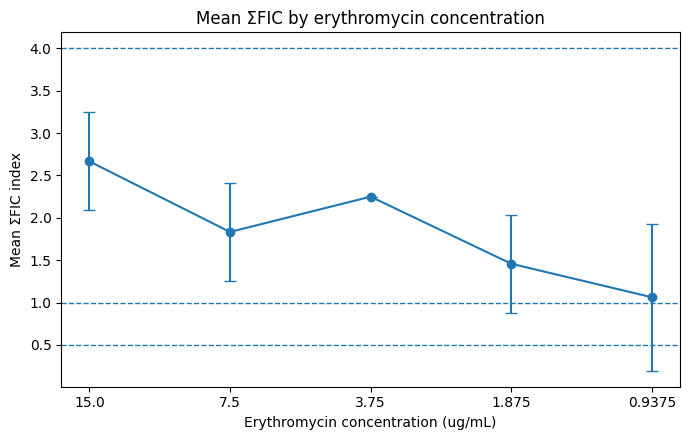

/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_83810/3281420160.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=[str(c) for c in ordered_cols])


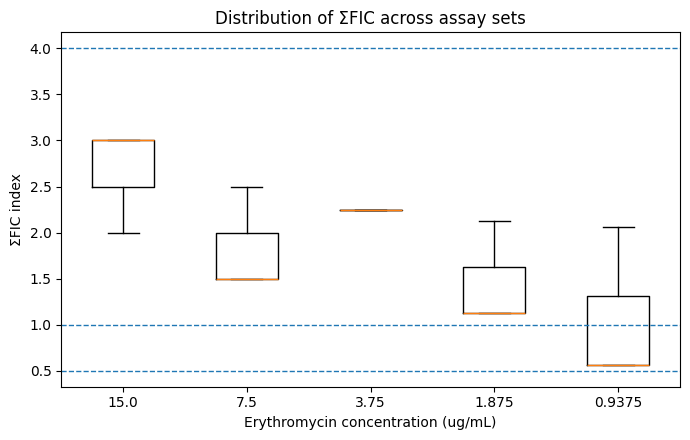

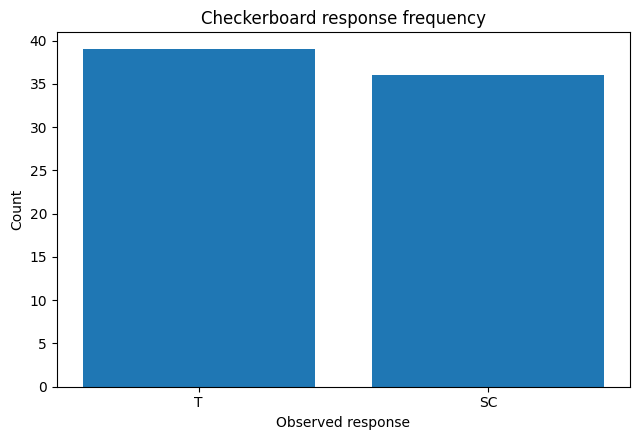

In [10]:
plt.figure(figsize=(7, 4.5))
x = summary["erythromycin_conc_ug_ml"].astype(str)
plt.errorbar(x, summary["mean_fic"], yerr=summary["sd_fic"].fillna(0), marker="o", capsize=4)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(4.0, linestyle="--", linewidth=1)
plt.xlabel("Erythromycin concentration (ug/mL)")
plt.ylabel("Mean ΣFIC index")
plt.title("Mean ΣFIC by erythromycin concentration")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
groups = [fic_df.loc[fic_df["erythromycin_conc_ug_ml"] == c, "computed_fic_index"] for c in ordered_cols]
plt.boxplot(groups, labels=[str(c) for c in ordered_cols])
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(4.0, linestyle="--", linewidth=1)
plt.xlabel("Erythromycin concentration (ug/mL)")
plt.ylabel("ΣFIC index")
plt.title("Distribution of ΣFIC across assay sets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.5))
plt.bar(response_counts["response"].astype(str), response_counts["count"])
plt.xlabel("Observed response")
plt.ylabel("Count")
plt.title("Checkerboard response frequency")
plt.tight_layout()
plt.show()

In [11]:
fic_df.to_csv(OUTPUT_DIR / "fic_long_dataset.csv", index=False)
response_df.to_csv(OUTPUT_DIR / "checkerboard_response_long.csv", index=False)
summary.to_csv(OUTPUT_DIR / "fic_summary_by_erythromycin.csv", index=False)
response_counts.to_csv(OUTPUT_DIR / "response_frequency_table.csv", index=False)
interpretation_counts.to_csv(OUTPUT_DIR / "fic_interpretation_frequency_table.csv", index=False)
mismatches.to_csv(OUTPUT_DIR / "interpretation_consistency_check.csv", index=False)
normality_df.to_csv(OUTPUT_DIR / "assumption_checks_normality.csv", index=False)

print(f"Outputs saved to: {OUTPUT_DIR.resolve()}")

Outputs saved to: /Users/freshliannes.rosal/Documents/Stat Client/Mary Project/statistical_analysis_outputs


In [12]:
print("Suggested Results Statement")
print(f"""The checkerboard assay was analyzed using MIC-derived ΣFIC values. Erythromycin-alone and carbon-dots-alone MICs were treated as reference values for FIC computation. Descriptive statistics were prioritized because only three assay sets were available. Across the 15 checkerboard combinations, the computed mean ΣFIC was {fic_df['computed_fic_index'].mean():.3f} ± {fic_df['computed_fic_index'].std():.3f}. Most combinations were classified as indifferent, while lower-concentration combinations included additive results. The Friedman repeated-measures test was not statistically significant, chi-square = {friedman_result.statistic:.3f}, p = {friedman_result.pvalue:.3f}; however, this result should be interpreted cautiously because of the small number of assay sets.""")

Suggested Results Statement
The checkerboard assay was analyzed using MIC-derived ΣFIC values. Erythromycin-alone and carbon-dots-alone MICs were treated as reference values for FIC computation. Descriptive statistics were prioritized because only three assay sets were available. Across the 15 checkerboard combinations, the computed mean ΣFIC was 1.854 ± 0.770. Most combinations were classified as indifferent, while lower-concentration combinations included additive results. The Friedman repeated-measures test was not statistically significant, chi-square = 7.200, p = 0.126; however, this result should be interpreted cautiously because of the small number of assay sets.
